<a href="https://colab.research.google.com/github/EzequielMovia/machine-learning-projects/blob/main/fraud-detection-ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Librerías
import pandas as pd
#Sirve para trabajar con tablas y cargar el dataset.

import numpy as np
#Se usa para operaciones matemáticas y arreglos.

# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import RobustScaler,StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, classification_report

from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings("ignore")
from sklearn.neural_network import MLPClassifier

importamos data set


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:


#importar el set de datos
df = pd.read_csv("/content/drive/MyDrive/parcialIA/banking_transactions.csv")
#df.rename(columns=)

In [ ]:
df.columns

Index(['transaction_id', 'transaction_amount', 'login_attempts',
       'device_risk_score', 'transfer_frequency', 'anomaly_score',
       'account_age_days', 'transaction_time_hour',
       'failed_transactions_last_30d', 'avg_monthly_balance',
       'daily_transaction_count', 'geo_distance_km',
       'session_duration_minutes', 'transaction_velocity_score',
       'payment_channel', 'authentication_type', 'card_present_flag',
       'international_transaction_flag', 'suspicious_ip_flag', 'fraud_flag'],
      dtype='object')

1. Chequear si en la base existen datos nulos

In [ ]:
# Verificamos si hay valores nulos en el dataset
# Verificamos la cantidad de valores nulos por columna
df.isnull().sum()

,0
transaction_id,0
transaction_amount,0
login_attempts,0
device_risk_score,0
transfer_frequency,0
anomaly_score,0
account_age_days,0
transaction_time_hour,0
failed_transactions_last_30d,0
avg_monthly_balance,0


Se verificó la existencia de valores nulos en todas las variables del conjunto de datos ninguna columna presenta valores faltantes, y no fue necesario realizar tratamientos adicionales sobre los datos.

In [ ]:
# Chequear cant info, nulos y tipos  de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  10000 non-null  int64  
 1   transaction_amount              10000 non-null  float64
 2   login_attempts                  10000 non-null  int64  
 3   device_risk_score               10000 non-null  float64
 4   transfer_frequency              10000 non-null  int64  
 5   anomaly_score                   10000 non-null  float64
 6   account_age_days                10000 non-null  int64  
 7   transaction_time_hour           10000 non-null  int64  
 8   failed_transactions_last_30d    10000 non-null  int64  
 9   avg_monthly_balance             10000 non-null  float64
 10  daily_transaction_count         10000 non-null  int64  
 11  geo_distance_km                 10000 non-null  int64  
 12  session_duration_minutes        1

In [ ]:
#.describe(): darnos un resumen estadistico por col num
df.describe()

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,card_present_flag,international_transaction_flag,suspicious_ip_flag
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.005000e+06,12412.754004,6.438900,50.257190,39.648400,0.348916,2510.240900,11.553600,12.437800,249367.527976,60.614300,7604.567500,60.479300,50.122240,0.492800,0.498400,0.500500
std,2.886896e+03,7200.700863,3.453558,29.414463,23.419868,0.236890,1436.335019,6.962254,7.532875,144580.006647,34.821533,4330.728784,34.833419,29.271512,0.499973,0.500022,0.500025
min,1.000001e+06,6.270000,1.000000,0.000000,0.000000,0.010000,6.000000,0.000000,0.000000,104.160000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.002501e+06,6174.025000,3.000000,25.100000,19.000000,0.170000,1271.750000,6.000000,6.000000,122291.355000,30.750000,3896.000000,30.000000,24.800000,0.000000,0.000000,0.000000
50%,1.005000e+06,12322.965000,6.000000,50.200000,40.000000,0.310000,2511.000000,11.000000,13.000000,249799.800000,60.000000,7645.000000,61.000000,50.150000,0.000000,0.000000,1.000000
75%,1.007500e+06,18619.650000,9.000000,75.500000,60.000000,0.480000,3746.250000,18.000000,19.000000,373146.842500,91.000000,11376.250000,91.000000,75.400000,1.000000,1.000000,1.000000
max,1.010000e+06,24997.520000,12.000000,100.000000,80.000000,0.990000,5000.000000,23.000000,25.000000,499968.250000,120.000000,14997.000000,120.000000,100.000000,1.000000,1.000000,1.000000


2- EDA

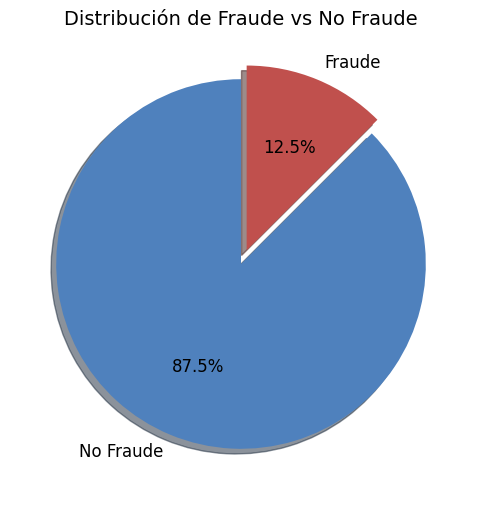

,Cantidad,Porcentaje (%)
fraud_flag,,
False,8749,87.49
True,1251,12.51


In [ ]:
# Distribucion de la variable objetivo
valores = df['fraud_flag'].value_counts()
porcentajes = df['fraud_flag'].value_counts(normalize=True) * 100

# Colores
colores = ['#4F81BD', '#C0504D']

# Grafico de torta
plt.figure(figsize=(7,6))

plt.pie(valores,
        labels=['No Fraude', 'Fraude'],
        autopct='%1.1f%%',
        startangle=90,
        colors=colores,
        explode=(0, 0.08),
        shadow=True,
        textprops={'fontsize':12})

plt.title('Distribución de Fraude vs No Fraude', fontsize=14)
plt.show()

# Tabla resumen
resumen = pd.DataFrame({
    'Cantidad': valores,
    'Porcentaje (%)': porcentajes.round(2)
})

display(resumen)

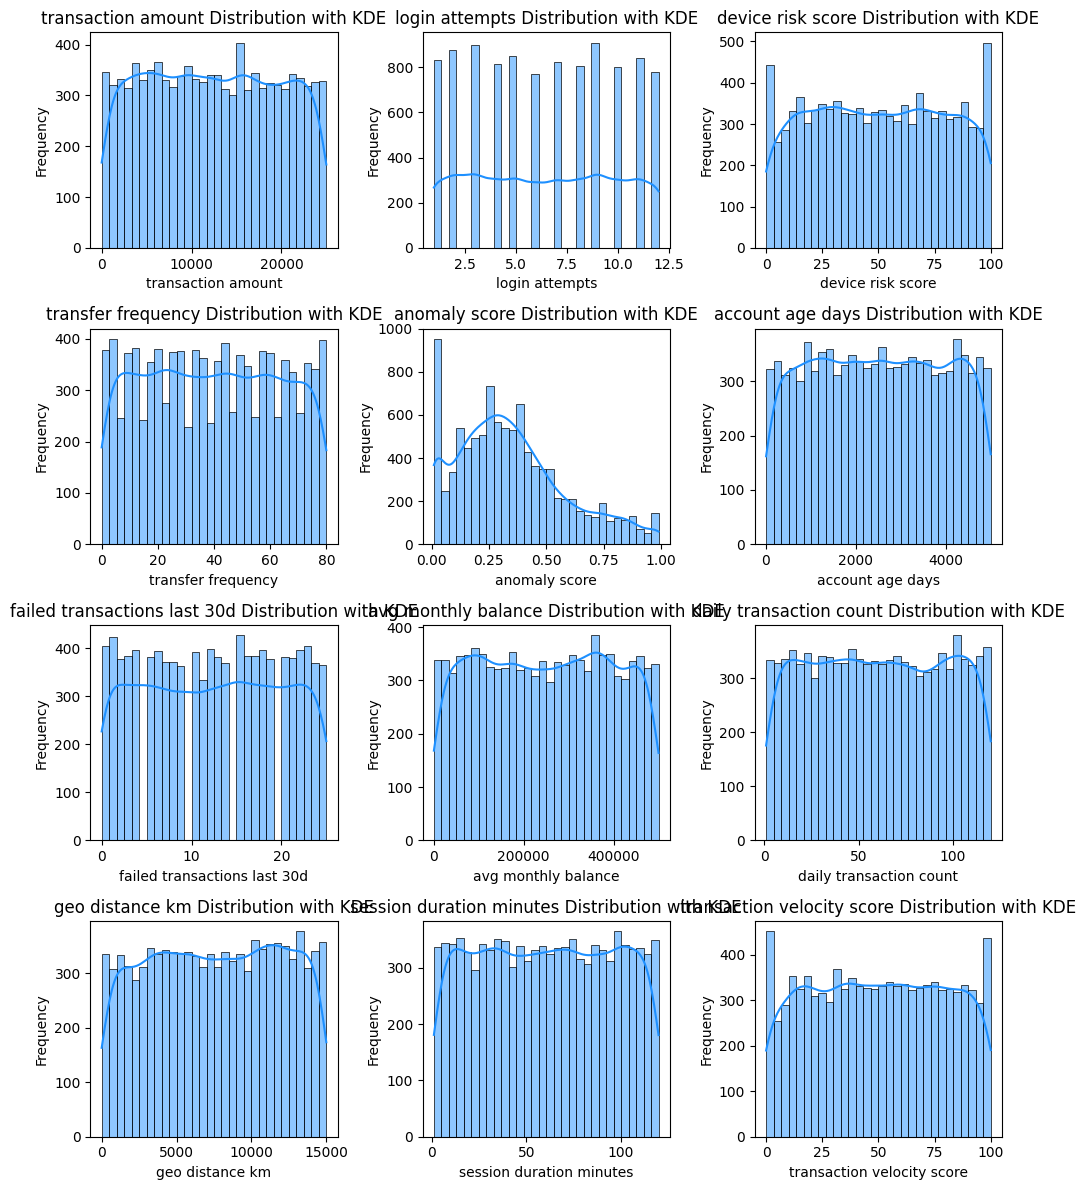

In [ ]:
# Histogramas con KDE para las variables numericas
# Funcion que grafica la distribucion de cada variable numerica con KDe
def univariate_analysis(data, columns):
    plt.figure(figsize=(10, 12))

    for i, column in enumerate(columns, 1):
        plt.subplot(4, 3, i)
        sns.histplot(data[column], kde=True, bins=30, color='dodgerblue')
        plt.title(f'{column.replace("_", " ")} Distribution with KDE')
        plt.xlabel(column.replace('_', ' '))
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()


columns_to_analyze = ['transaction_amount', 'login_attempts', 'device_risk_score',
                      'transfer_frequency', 'anomaly_score', 'account_age_days',
                      'failed_transactions_last_30d', 'avg_monthly_balance',
                      'daily_transaction_count', 'geo_distance_km',
                      'session_duration_minutes', 'transaction_velocity_score']

univariate_analysis(df, columns_to_analyze)

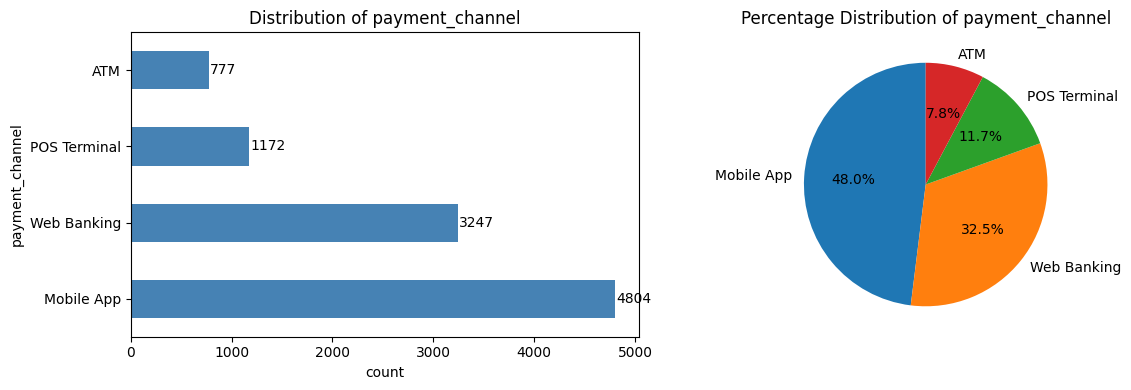

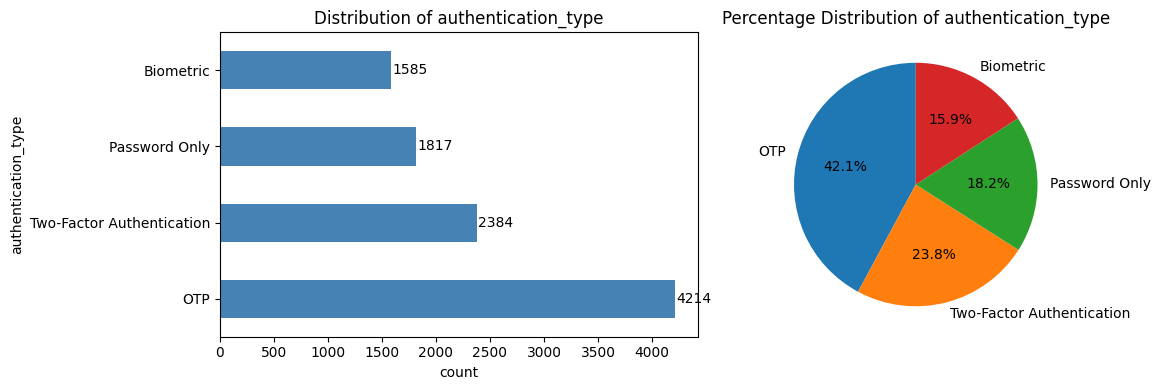

In [ ]:
# Distribucion de variables categoricas
categoricas = ['payment_channel', 'authentication_type']

for col in categoricas:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    valores = df[col].value_counts()
    porcentajes = df[col].value_counts(normalize=True) * 100

    # Barras horizontales
    valores.plot(kind='barh', ax=ax1, color='steelblue')
    for i, v in enumerate(valores):
        ax1.text(v + 10, i, str(v), va='center')
    ax1.set_title(f'Distribution of {col}')
    ax1.set_xlabel('count')

    # Torta
    ax2.pie(valores, labels=valores.index, autopct='%1.1f%%', startangle=90)
    ax2.set_title(f'Percentage Distribution of {col}')

    plt.tight_layout()
    plt.show()



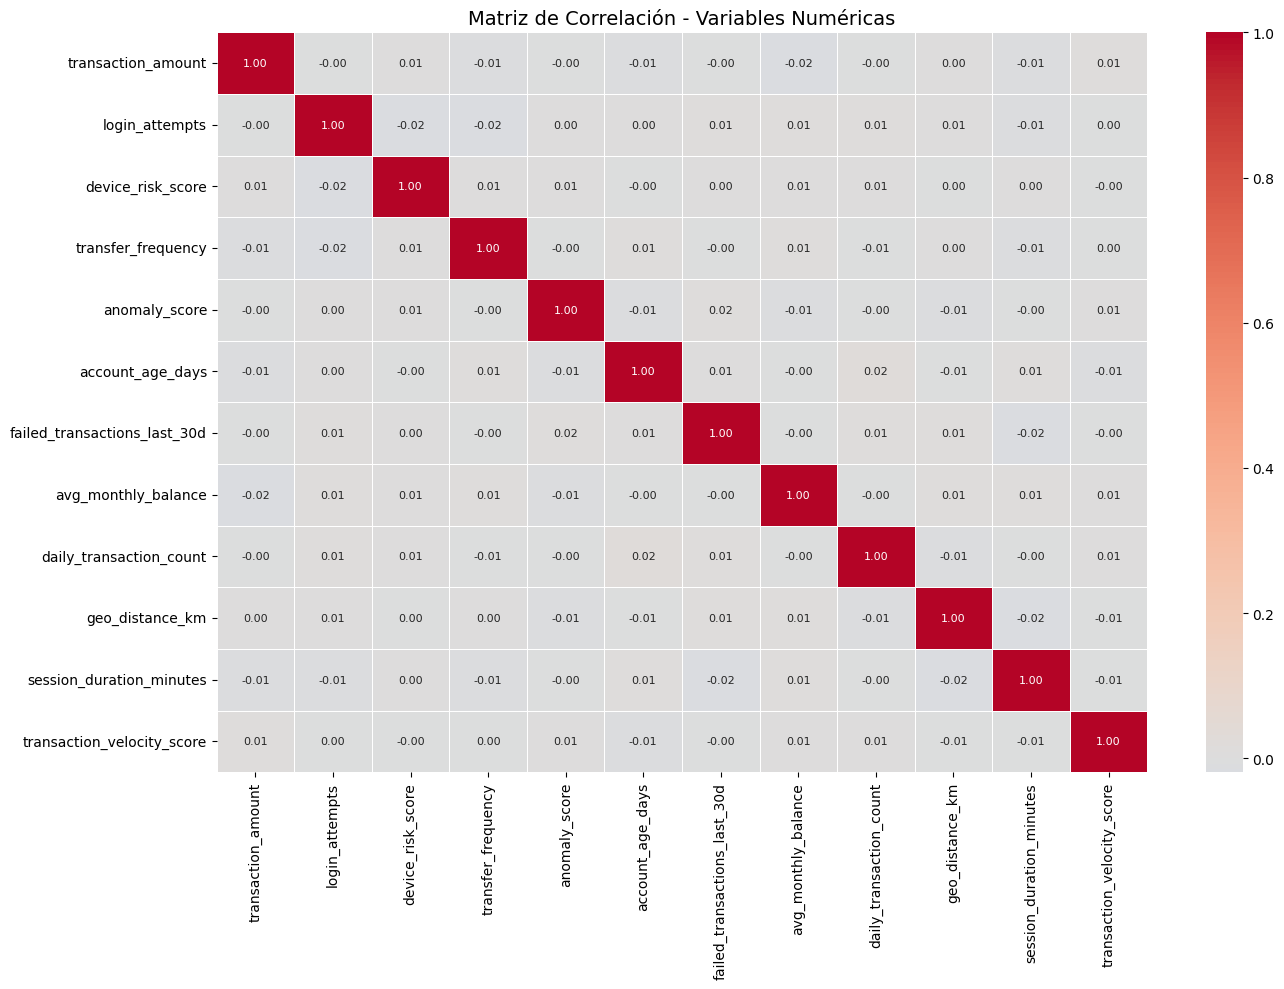

In [ ]:
# Matriz de correlacion entre variables numericas
plt.figure(figsize=(14, 10))

correlacion = df[columns_to_analyze].corr()

sns.heatmap(correlacion,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 8})

plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

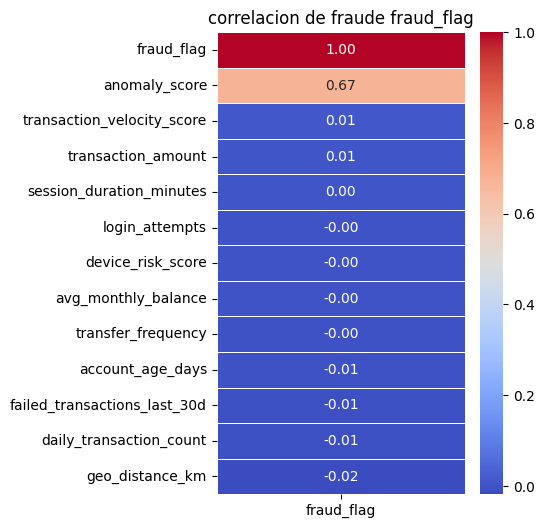

In [ ]:
# Extract correlation values with respect to the target variable (loan_status)
target_variable = 'fraud_flag'
target_corr = corr_matrix[[target_variable]].sort_values(by=target_variable, ascending=False)

# Plotting the heatmap for correlation values with respect to the target variable
plt.figure(figsize=(4, 6))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'correlacion de fraude {target_variable}')
plt.show()

3. Chequear si existen outliers en las variables. En caso de que existan, definir un
criterio para eliminarlos si corresponde.

In [ ]:
# Variables numericas
variables_numericas = df.select_dtypes(include=np.number).columns

# Total de registros
total_filas = len(df)

# Detectar outliers y calcular porcentaje
for columna in variables_numericas:

    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    cantidad_outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ].shape[0]

    porcentaje = (cantidad_outliers / total_filas) * 100

    print(f"{columna}: {cantidad_outliers} outliers ({porcentaje:.2f}%)")

transaction_id: 0 outliers (0.00%)
transaction_amount: 0 outliers (0.00%)
login_attempts: 0 outliers (0.00%)
device_risk_score: 0 outliers (0.00%)
transfer_frequency: 0 outliers (0.00%)
anomaly_score: 162 outliers (1.62%)
account_age_days: 0 outliers (0.00%)
transaction_time_hour: 0 outliers (0.00%)
failed_transactions_last_30d: 0 outliers (0.00%)
avg_monthly_balance: 0 outliers (0.00%)
daily_transaction_count: 0 outliers (0.00%)
geo_distance_km: 0 outliers (0.00%)
session_duration_minutes: 0 outliers (0.00%)
transaction_velocity_score: 0 outliers (0.00%)
card_present_flag: 0 outliers (0.00%)
international_transaction_flag: 0 outliers (0.00%)
suspicious_ip_flag: 0 outliers (0.00%)


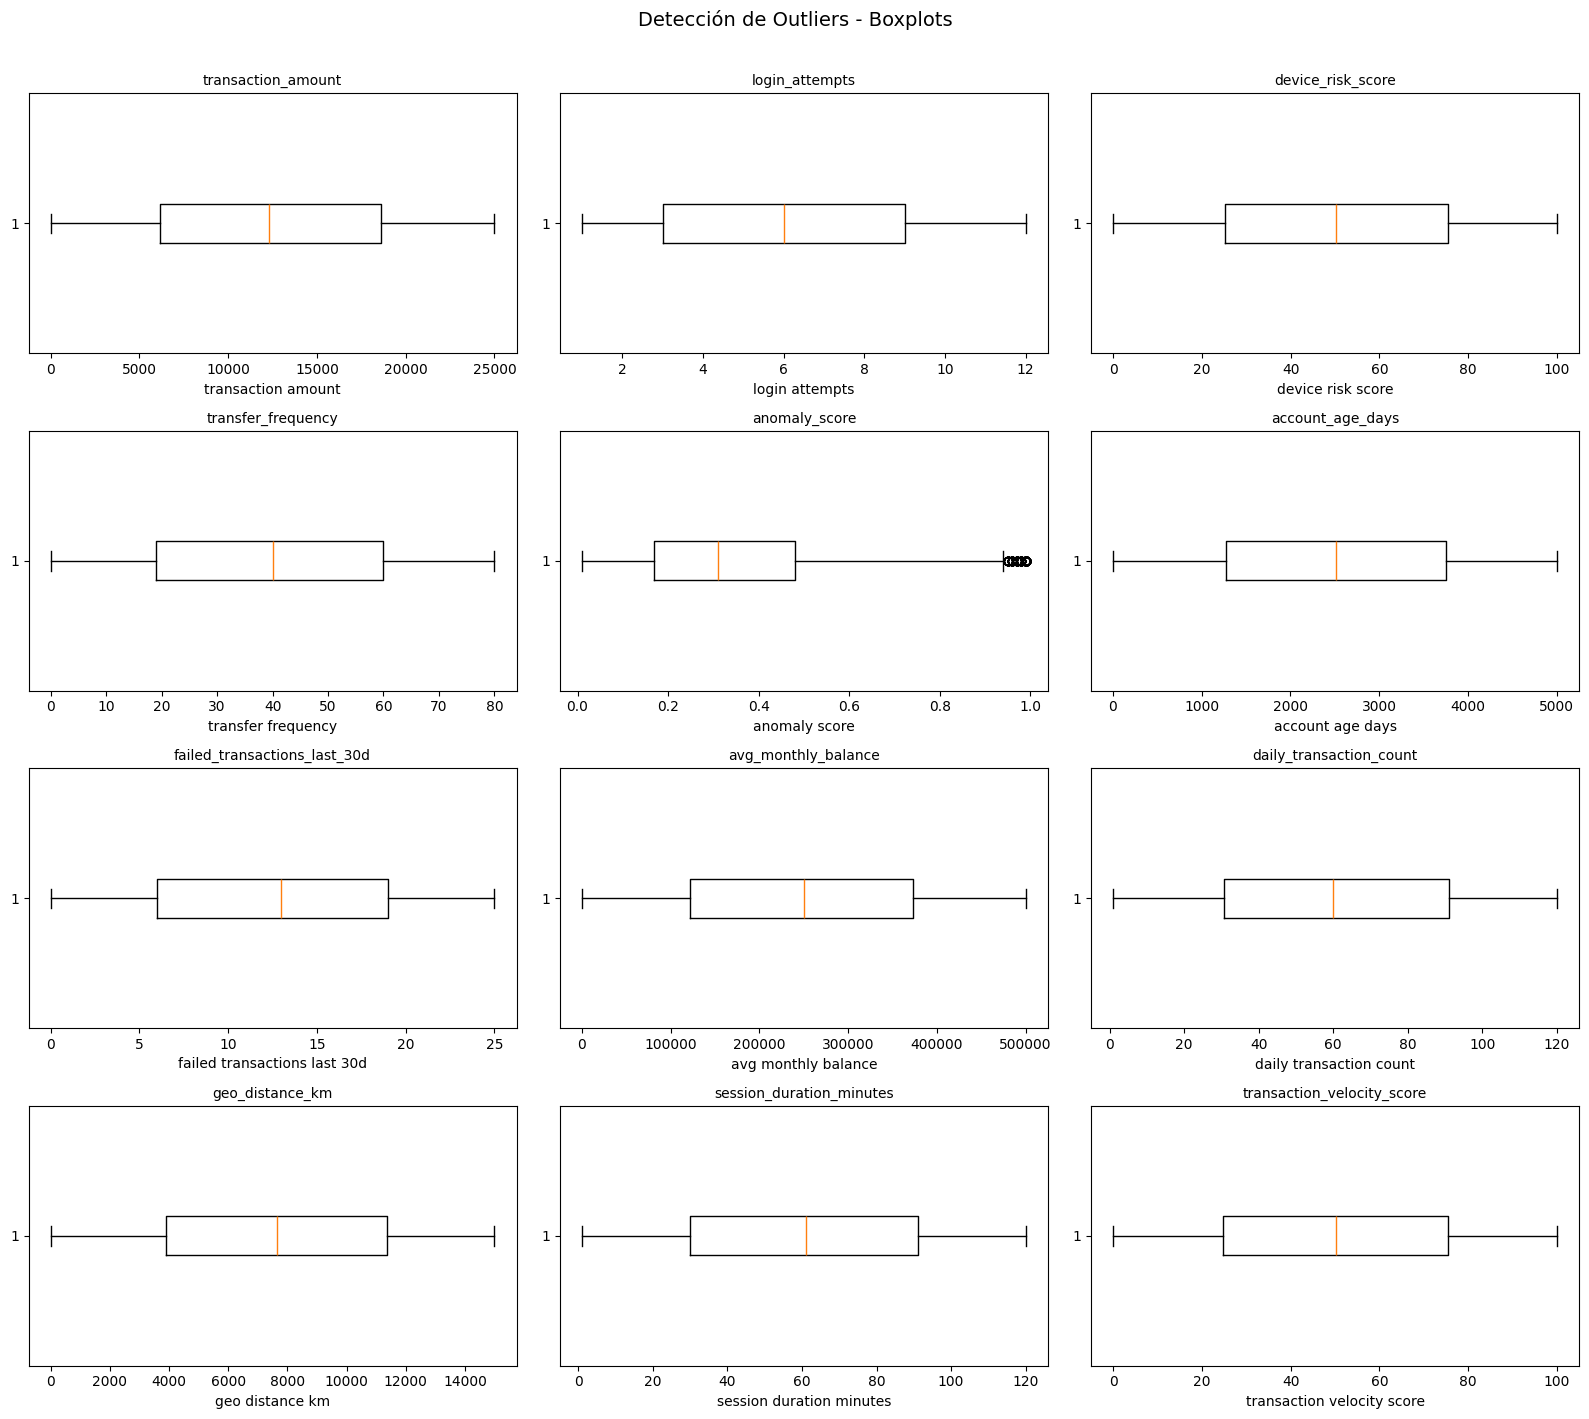

In [ ]:
# Boxplots para visualizar outliers
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(columns_to_analyze):
    axes[i].boxplot(df[col], vert=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel(col.replace('_', ' '))

plt.suptitle('Detección de Outliers - Boxplots', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

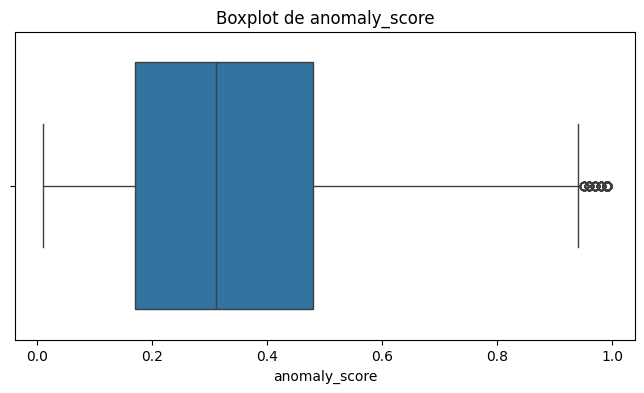

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['anomaly_score'])

plt.title('Boxplot de anomaly_score')
plt.show()

Se decide no eliminar los casos atipicos ya que el procentaje el muy peueño (1.62%) y esos datos pueden servir a futuropara futura informacion.

4. Separar en subconjuntos de entrenamiento y de prueba.

In [ ]:
# Separamos variable objetivo (y) de las variables independientes (X)

X = df.drop(columns=['fraud_flag', 'transaction_id'])
y = df['fraud_flag']

# Separamos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total de datos: {len(df)}")
print(f"Entrenamiento: {len(X_train)} filas ({len(X_train)/len(df)*100:.0f}%)")
print(f"Prueba:        {len(X_test)} filas ({len(X_test)/len(df)*100:.0f}%)")

Total de datos: 10000
Entrenamiento: 8000 filas (80%)
Prueba:        2000 filas (20%)


5. Realizar la transformación de las variables categóricas, para que sean categóricas
numéricas o dummy.

In [ ]:
# Convertimos las variables categóricas en dummies
X_train = pd.get_dummies(X_train, columns=['payment_channel', 'authentication_type'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['payment_channel', 'authentication_type'], drop_first=True)

print("Columnas después de la transformación:")
print(X_train.columns.tolist())
print(f"\nNueva forma de X_train: {X_train.shape}")

Columnas después de la transformación:
['transaction_id', 'transaction_amount', 'login_attempts', 'device_risk_score', 'transfer_frequency', 'anomaly_score', 'account_age_days', 'transaction_time_hour', 'failed_transactions_last_30d', 'avg_monthly_balance', 'daily_transaction_count', 'geo_distance_km', 'session_duration_minutes', 'transaction_velocity_score', 'card_present_flag', 'international_transaction_flag', 'suspicious_ip_flag', 'payment_channel_Mobile App', 'payment_channel_POS Terminal', 'payment_channel_Web Banking', 'authentication_type_OTP', 'authentication_type_Password Only', 'authentication_type_Two-Factor Authentication']

Nueva forma de X_train: (8000, 23)


In [ ]:
# Eliminamos transaction_id que no aporta informacion
X_train = X_train.drop(columns=['transaction_id'])
X_test = X_test.drop(columns=['transaction_id'])

print(f"Nueva forma de X_train: {X_train.shape}")

Nueva forma de X_train: (8000, 22)


6. Estandarizar los subconjuntos de variables independientes.

In [ ]:
# Estandarizamos las variables numéricas
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Estandarización completada")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Estandarización completada
X_train shape: (8000, 22)
X_test shape: (2000, 22)


7. Entrenar el modelo de clasificación por redes neuronales.  

In [ ]:
# Entrenamos la red neuronal de clasificación
modelo = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


8. Exponer los resultados del modelo.  

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import multiprocessing

# Espacio de búsqueda de hiperparámetros
param_distributions = {
    'hidden_layer_sizes': [(64, 32), (100, 50), (50,), (100,)],
    'alpha': np.logspace(-3, 1, 7),
    'learning_rate_init': [0.001, 0.01],
    'solver': ['adam']
}

# Modelo base sin hiperparametros fijos
modelo_base = MLPClassifier(max_iter=500, random_state=42, early_stopping=True)

# Busqueda aleatoria
grid = RandomizedSearchCV(
    estimator=modelo_base,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='accuracy',
    n_jobs=multiprocessing.cpu_count() - 1,
    cv=4,
    random_state=42,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nMejores hiperparámetros encontrados:")
print(grid.best_params_)
print(f"\nMejor accuracy en validación: {grid.best_score_:.4f}")

Fitting 4 folds for each of 20 candidates, totalling 80 fits

Mejores hiperparámetros encontrados:
{'solver': 'adam', 'learning_rate_init': 0.001, 'hidden_layer_sizes': (100,), 'alpha': np.float64(0.1)}

Mejor accuracy en validación: 0.9472


Accuracy entrenamiento: 0.9507
Accuracy prueba:        0.9510

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

       False       0.97      0.98      0.97      1751
        True       0.84      0.75      0.79       249

    accuracy                           0.95      2000
   macro avg       0.90      0.87      0.88      2000
weighted avg       0.95      0.95      0.95      2000



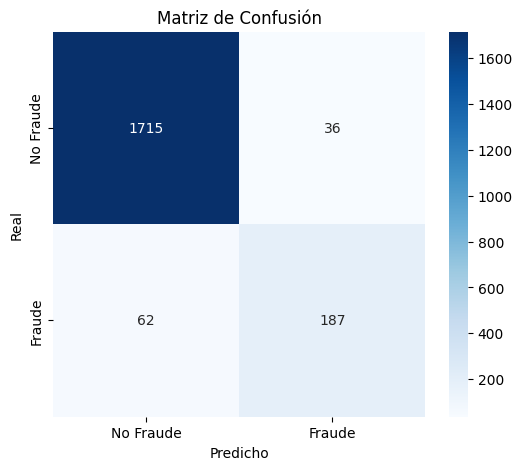

In [ ]:
# Predicciones con el mejor modelo encontrado
y_pred = grid.predict(X_test)

# Comparamos train vs test para verificar sobreajuste
print(f"Accuracy entrenamiento: {grid.score(X_train, y_train):.4f}")
print(f"Accuracy prueba:        {grid.score(X_test, y_test):.4f}")

# Reporte de clasificacion
print("\n=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred))

# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fraude', 'Fraude'],
            yticklabels=['No Fraude', 'Fraude'])
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

In [ ]:
# Tabla con los resultados de todas las combinaciones probadas
resultados = pd.DataFrame(grid.cv_results_)
resultados.filter(regex='(param.*|mean_t|std_t)')\
    .drop(columns='params')\
    .sort_values('mean_test_score', ascending=False)\
    .head(10)

,param_solver,param_learning_rate_init,param_hidden_layer_sizes,param_alpha,mean_test_score,std_test_score
13,adam,0.001,"(100,)",0.100000,0.947250,0.002795
1,adam,0.010,"(50,)",0.001000,0.946875,0.003489
7,adam,0.001,"(100, 50)",0.100000,0.946875,0.001980
2,adam,0.010,"(64, 32)",0.464159,0.946750,0.002839
16,adam,0.001,"(100,)",0.001000,0.946750,0.000829
3,adam,0.010,"(50,)",0.004642,0.946750,0.003400
18,adam,0.010,"(64, 32)",2.154435,0.946625,0.002678
12,adam,0.001,"(100, 50)",0.464159,0.946250,0.002250
6,adam,0.001,"(50,)",0.464159,0.946250,0.001887
0,adam,0.001,"(64, 32)",0.001000,0.946000,0.001803


In [ ]:
# Mostramos el resumen final del modelo optimizado
mejor_modelo = grid.best_estimator_

y_pred_train = mejor_modelo.predict(X_train)
y_pred_test = mejor_modelo.predict(X_test)

print("=== Resumen Final del Modelo ===\n")
print(f"Train Score:  {mejor_modelo.score(X_train, y_train) * 100}")
print(f"Test Score:   {mejor_modelo.score(X_test, y_test) * 100}")
print(f"Accuracy:     {accuracy_score(y_test, y_pred_test) * 100}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report")
print(classification_report(y_test, y_pred_test))

=== Resumen Final del Modelo ===

Train Score:  95.075
Test Score:   95.1
Accuracy:     95.1

Confusion Matrix:
[[1715   36]
 [  62  187]]

Classification Report
              precision    recall  f1-score   support

       False       0.97      0.98      0.97      1751
        True       0.84      0.75      0.79       249

    accuracy                           0.95      2000
   macro avg       0.90      0.87      0.88      2000
weighted avg       0.95      0.95      0.95      2000



9. Exponer el modelo y los hiper-parámetros utilizados describiendo porque cree que
son los mejores para el problema de clasificación de futuras observaciones.

El modelo utilizado fue una Red Neuronal MLP de clasificacion. Para encontrar los mejores hiperparametros use RandomizedSearchCV que probo 20 combinaciones distintas y eligió la que mejor resultado dio.
Los hiperparametros elegidos fueron:

hidden_layer_sizes=(100,): una sola capa oculta con 100 neuronas. Fue suficiente para aprender los patrones del dataset.
alpha=0.1: evita que el modelo se memorice los datos de entrenamiento.
learning_rate_init=0.001: controla qué tan rapido aprende el modelo. Un valor bajo hace que aprenda de forma más estable.
solver=adam: es el optimizador que ajusta los pesos de la red durante el entrenamiento. Es el mas usado y eficiente.

Resultados obtenidos:

Train Score: 95.07%
Test Score: 95.10%

Como el Train Score y el Test Score son casi iguales. El modelo no presenta sobreajuste y va a funcionar bien clasificando transacciones nuevas que no vio durante el entrenamiento.